In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# 1. Dati Sperimentali
t_exp = np.array([1.0, 24.0, 96.0])
A0_exp = np.array([50.0, 200.0, 350.0])
bg = np.array([0.004199309, 0.003368672, 0.000942459])

A_int_raw = np.array([
    [0.023594163, 0.146368766, 0.105341900],  # A0 = 50 kBq/mL
    [0.092211399, 0.349493079, 0.218233662],  # A0 = 200 kBq/mL
    [0.076153440, 0.443769956, 0.231148121]   # A0 = 350 kBq/mL
])

err_matrix = np.array([
    [0.004641692, 0.026652162, 0.039304734],
    [0.109901502, 0.064321945, 0.068945026],
    [0.074465535, 0.055049521, 0.099395703]
])

# Dati netti sottratto il background
A_int_net = np.maximum(A_int_raw - bg, 1e-6)

# Parametri fisici radionuclide (Ag-111)
T_half = 7.45 * 24.0  # 178.8 ore
lmbda = np.log(2) / T_half

In [2]:
def analizza_e_grafica_modello(fit_result, param_names, model_name, ode_func):
    res = fit_result.fun  # Residui pesati: (predetto - osservato) / errore
    J = fit_result.jac
    p = len(fit_result.x)
    N = len(res)
    dof = N - p
    ssq = 2 * fit_result.cost  # Chi-quadro totale
    chi2_red = ssq / dof if dof > 0 else np.nan
    
    # Calcolo della matrice di covarianza e correlazione
    try:
        cov = np.linalg.pinv(J.T @ J) * chi2_red
        std_err = np.sqrt(np.diag(cov))
        corr = cov / np.outer(std_err, std_err)
    except Exception:
        corr = np.eye(p)
        std_err = np.zeros(p)
    
    # Stampa parametri e diagnostica
    print(f"==================================================")
    print(f" DIAGNOSTICA FIT: {model_name}")
    print(f"==================================================")
    print(f"Chi2 Totale (SSQ) : {ssq:.4f}")
    print(f"Gradi di Libertà  : {dof}")
    print(f"Chi2 Ridotto      : {chi2_red:.4f}  (Ottimale se vicino a 1.0)")
    print("-" * 50)
    print(f"{'Parametro':<12} | {'Valore':<14} | {'Incertezza (± StdErr)'}")
    print("-" * 50)
    for name, val, err in zip(param_names, fit_result.x, std_err):
        print(f"{name:<12} | {val:<14.6e} | ± {err:.6e}")
    print("=" * 50 + "\n")

    # Layout Grafici: 1 riga x 3 colonne (Fit, Residui, Correlazione)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    t_dense = np.linspace(0, 96, 200)

    # 1. Grafico del Fit (Dati sperimentali con Errorbar vs Curva Modello)
    for i, A0 in enumerate(A0_exp):
        # Riconosce automaticamente lo stato iniziale (2 o 3 variabili di stato)
        try:
            ode_func(0, [A0, 0.0, 1.0], *fit_result.x)
            y0 = [A0, 0.0, 1.0]
        except Exception:
            y0 = [A0, 0.0]
            
        sol_dense = solve_ivp(ode_func, (0, 96), y0, args=tuple(fit_result.x),
                              t_eval=t_dense, method='RK45', rtol=1e-6, atol=1e-8)
        
        # Punti sperimentali con barre d'errore
        axes[0].errorbar(t_exp, A_int_net[i, :], yerr=err_matrix[i, :], fmt='o', 
                         color=colors[i], capsize=4, elinewidth=1.2, label=f'Dati $A_0$={A0}')
        # Curva continua del modello
        axes[0].plot(sol_dense.t, sol_dense.y[1], '-', color=colors[i], 
                     linewidth=2, label=f'Fit $A_0$={A0}')
        
    axes[0].set_title(f'Fit del Modello')
    axes[0].set_xlabel('Tempo (h)')
    axes[0].set_ylabel('Attività Intracellulare Netta (Bq/cell)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    # 2. Grafico dei Residui Pesati
    res_matrix = res.reshape(3, 3)
    for i, A0 in enumerate(A0_exp):
        axes[1].plot(t_exp, res_matrix[i, :], 'o--', label=f'$A_0$ = {A0} kBq/mL', color=colors[i])
    axes[1].axhline(0, color='red', linestyle=':', linewidth=1.5)
    axes[1].set_title(f'Residui Pesati')
    axes[1].set_xlabel('Tempo (h)')
    axes[1].set_ylabel(r'$\frac{A_{pred} - A_{exp}}{\sigma}$')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)
    
    # 3. Heatmap Matrice di Correlazione
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="vlag", vmin=-1, vmax=1,
                xticklabels=param_names, yticklabels=param_names, ax=axes[2], cbar=True)
    axes[2].set_title(f'Matrice di Correlazione')
    
    plt.tight_layout()
    plt.show()

 DIAGNOSTICA FIT: Tuo Modello (4 Parametri)
Chi2 Totale (SSQ) : 1.1744
Gradi di Libertà  : 5
Chi2 Ridotto      : 0.2349  (Ottimale se vicino a 1.0)
--------------------------------------------------
Parametro    | Valore         | Incertezza (± StdErr)
--------------------------------------------------
kin          | 3.705947e-04   | ± 4.504679e-05
kout         | 6.622689e-02   | ± 2.746823e-02
alpha        | 2.735081e-01   | ± 1.313278e-01
gamma        | 2.144280e-02   | ± 7.710405e-03



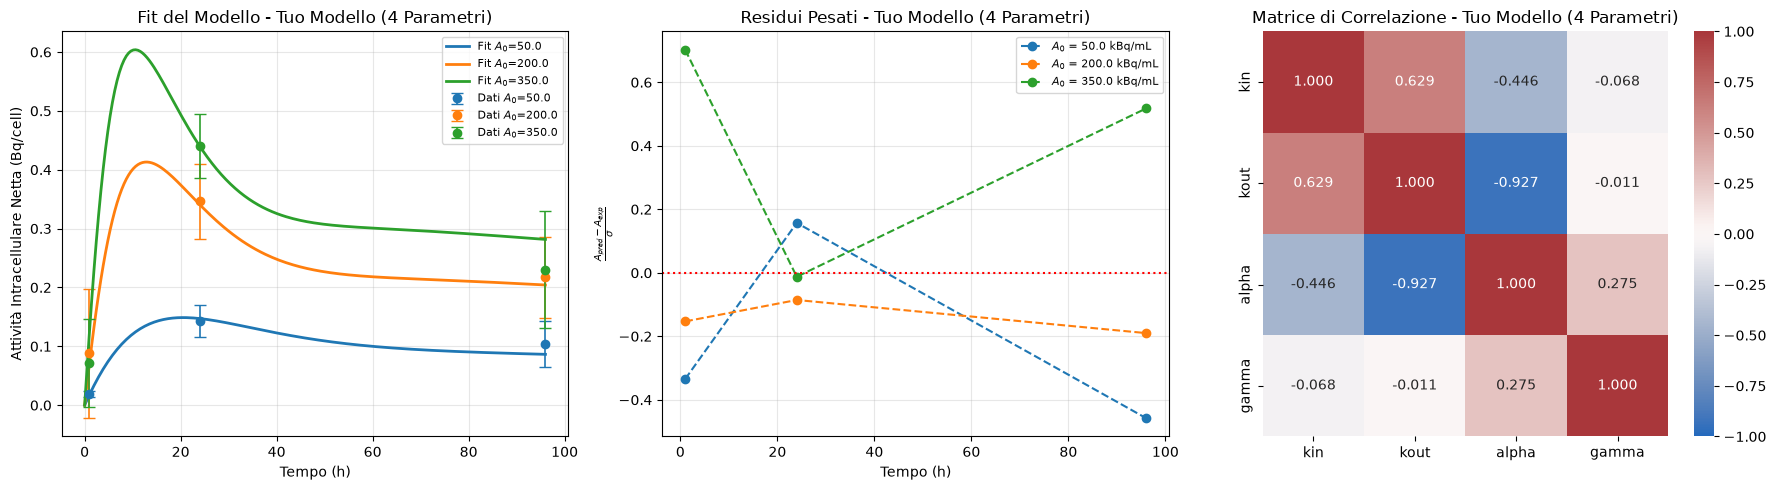

In [ ]:

# Modello mio con 4 parametri

def ode_user4(t, y, kin, kout, alpha, gamma):
    Am, Acell, C = y
    dAm    = - lmbda * Am - kin * C * Am + kout * Acell
    dAcell = - lmbda * Acell + kin * C * Am - kout * Acell
    dC     = - alpha * C * Acell + gamma * (1.0 - C)
    return [dAm, dAcell, dC]

def residuali_user4(params):
    kin, kout, alpha, gamma = params
    pred = np.zeros((3, 3))
    for i, A0 in enumerate(A0_exp):
        sol = solve_ivp(ode_user4, (0, 96), [A0, 0.0, 1.0], args=(kin, kout, alpha, gamma),
                        t_eval=t_exp, method='RK45', rtol=1e-6, atol=1e-8)
        pred[i, :] = sol.y[1]
    return ((pred - A_int_net) / err_matrix).ravel()

# Esecuzione Fit
fit_user4 = least_squares(
    residuali_user4, 
    x0=[0.001, 0.05, 0.1, 0.05], 
    bounds=([1e-6, 1e-6, 0.0, 1e-6], [1.0, 1.0, 10.0, 1.0])
)

# Analisi e Grafici
analizza_e_grafica_modello(fit_user4, ['kin', 'kout', 'alpha', 'gamma'], "Tuo Modello (4 Parametri)", ode_user4)

 DIAGNOSTICA FIT: Tuo Modello Ridotto (3 Parametri)
Chi2 Totale (SSQ) : 8.1815
Gradi di Libertà  : 6
Chi2 Ridotto      : 1.3636  (Ottimale se vicino a 1.0)
--------------------------------------------------
Parametro    | Valore         | Incertezza (± StdErr)
--------------------------------------------------
kin          | 4.289981e-04   | ± 1.159858e-04
kout         | 1.725822e-01   | ± 6.645301e-02
alpha        | 4.815239e-02   | ± 3.004825e-02



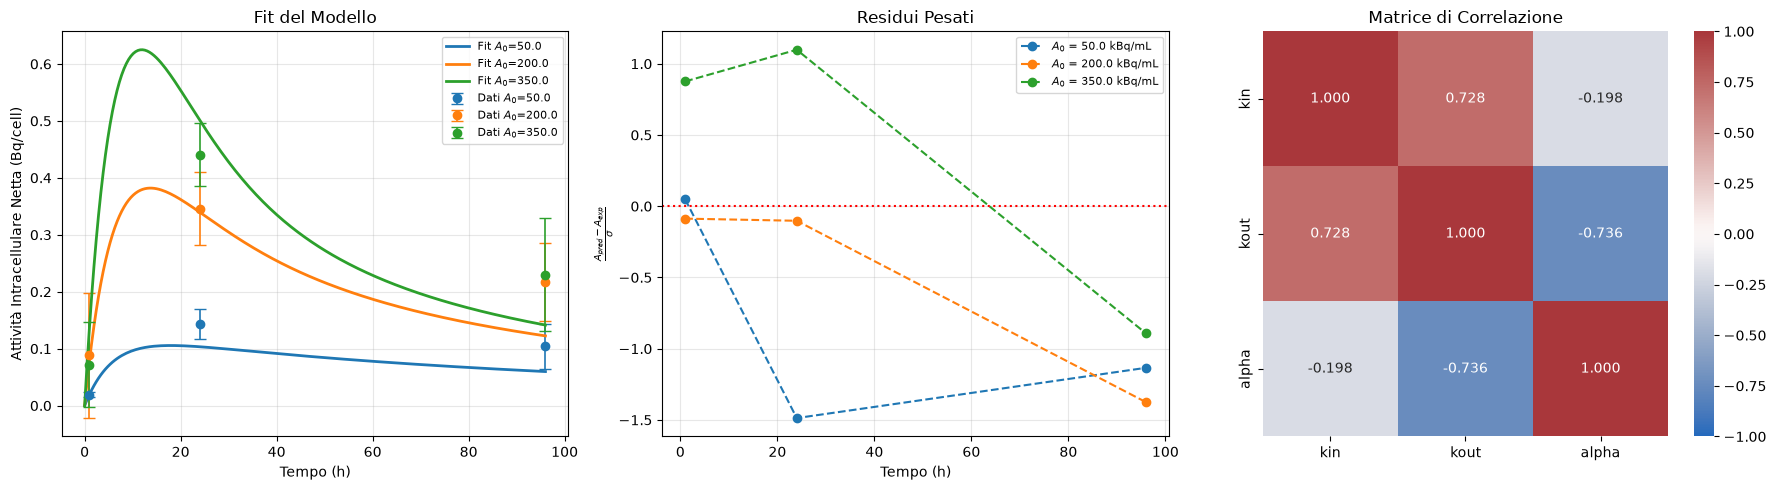

In [3]:
# Modello mio con gamma = 0; 3 parametri

def ode_user3(t, y, kin, kout, alpha):
    Am, Acell, C = y
    dAm    = - lmbda * Am - kin * C * Am + kout * Acell
    dAcell = - lmbda * Acell + kin * C * Am - kout * Acell
    dC     = - alpha * C * Acell
    return [dAm, dAcell, dC]

def residuali_user3(params):
    kin, kout, alpha = params
    pred = np.zeros((3, 3))
    for i, A0 in enumerate(A0_exp):
        sol = solve_ivp(ode_user3, (0, 96), [A0, 0.0, 1.0], args=(kin, kout, alpha),
                        t_eval=t_exp, method='RK45', rtol=1e-6, atol=1e-8)
        pred[i, :] = sol.y[1]
    return ((pred - A_int_net) / err_matrix).ravel()

# Esecuzione Fit
fit_user3 = least_squares(
    residuali_user3, 
    x0=[0.001, 0.05, 0.1], 
    bounds=([1e-6, 1e-6, 0.0], [1.0, 1.0, 10.0])
)

# Analisi e Grafici
analizza_e_grafica_modello(fit_user3, ['kin', 'kout', 'alpha'], "Tuo Modello Ridotto (3 Parametri)", ode_user3)

 DIAGNOSTICA FIT: Modello M-M (4 Parametri)
Chi2 Totale (SSQ) : 0.2057
Gradi di Libertà  : 5
Chi2 Ridotto      : 0.0411  (Ottimale se vicino a 1.0)
--------------------------------------------------
Parametro    | Valore         | Incertezza (± StdErr)
--------------------------------------------------
V            | 1.060472e-01   | ± 1.024932e-02
K            | 2.032304e+02   | ± 2.106511e+01
a            | 2.050924e-02   | ± 2.872566e-03
b            | 1.231139e-01   | ± 8.910367e-03



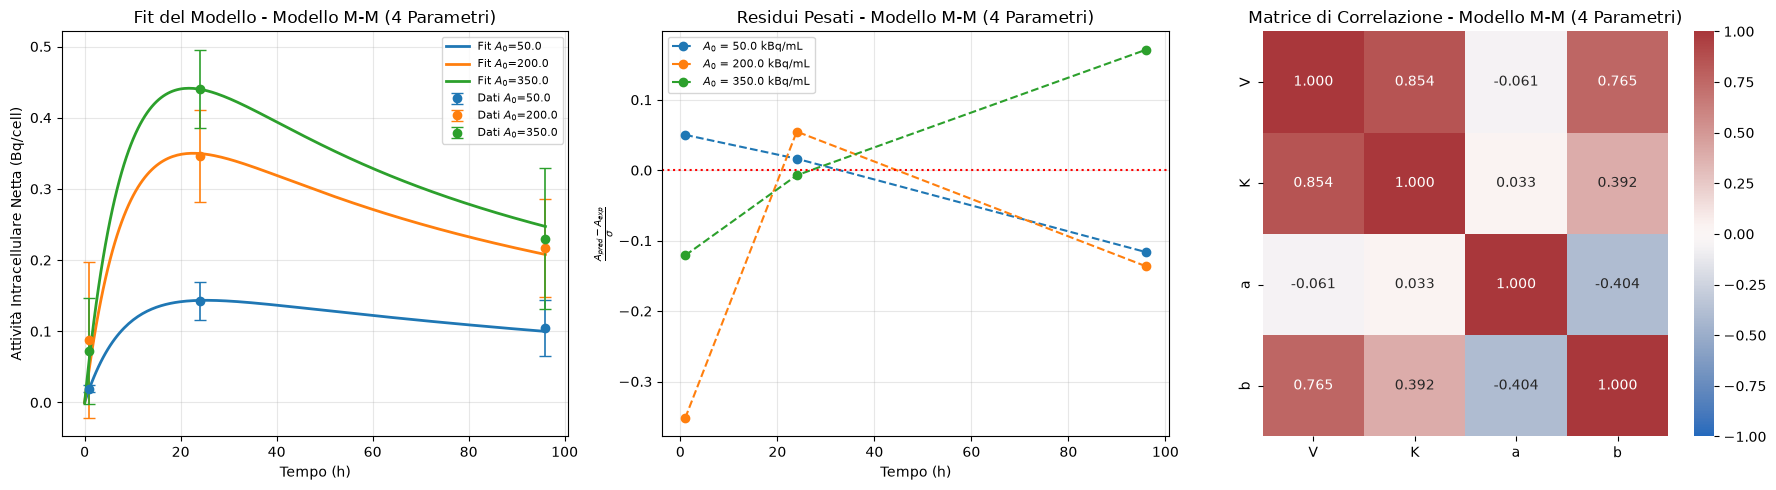

In [10]:
# Modello 4 parametri, M M 

def ode_tutor_mm4(t, y, V, K, a, b):
    A1, A2, R = y
    mm_term = V * R * A1 / (K + A1)
    dA1 = - lmbda * A1 - mm_term + b * A2
    dA2 = - lmbda * A2 + mm_term - b * A2
    dR  = - a * R * A2
    return [dA1, dA2, dR]

def residuali_tutor_mm4(params):
    V, K, a, b = params
    pred = np.zeros((3, 3))
    for i, A0 in enumerate(A0_exp):
        sol = solve_ivp(ode_tutor_mm4, (0, 96), [A0, 0.0, 1.0], args=(V, K, a, b),
                        t_eval=t_exp, method='RK45', rtol=1e-6, atol=1e-8)
        pred[i, :] = sol.y[1]
    return ((pred - A_int_net) / err_matrix).ravel()

# Esecuzione Fit
fit_tutor_mm4 = least_squares(
    residuali_tutor_mm4, 
    x0=[0.1, 100.0, 0.1, 0.05], 
    bounds=([1e-6, 1e-3, 0.0, 1e-6], [10.0, 10000.0, 10.0, 1.0])
)

# Analisi e Grafici
analizza_e_grafica_modello(fit_tutor_mm4, ['V', 'K', 'a', 'b'], "Modello M-M (4 Parametri)", ode_tutor_mm4)

 DIAGNOSTICA FIT: Modello Lineare (Diff. Esponenziali - 2 Parametri)
Chi2 Totale (SSQ) : 13.5543
Gradi di Libertà  : 7
Chi2 Ridotto      : 1.9363  (Ottimale se vicino a 1.0)
--------------------------------------------------
Parametro    | Valore         | Incertezza (± StdErr)
--------------------------------------------------
c            | 4.150901e-04   | ± 1.530493e-04
b            | 2.651421e-01   | ± 1.038715e-01



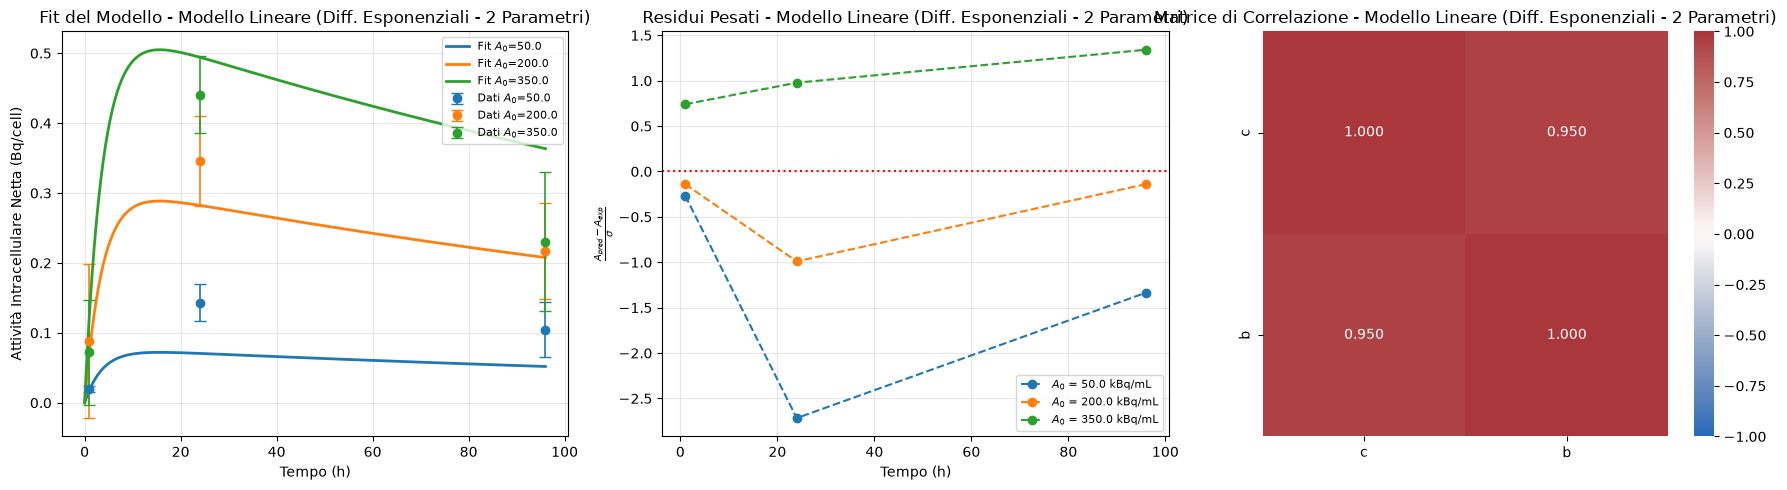

In [6]:
# =============================================================================
# MODELLO LINEARE A 2 COMPARTIMENTI (Differenza di Esponenziali)
# Equazioni:
#   dA1/dt = - lambda*A1 - c*A1
#   dA2/dt = - lambda*A2 + c*A1 - b*A2
# Parametri (p=2): c (rate in), b (efflusso out)
# =============================================================================

def ode_linear2(t, y, c, b):
    A1, A2 = y
    dA1 = - lmbda * A1 - c * A1
    dA2 = - lmbda * A2 + c * A1 - b * A2
    return [dA1, dA2]

def residuali_linear2(params):
    c, b = params
    pred = np.zeros((3, 3))
    for i, A0 in enumerate(A0_exp):
        sol = solve_ivp(
            ode_linear2, 
            (0, 96), 
            [A0, 0.0], 
            args=(c, b),
            t_eval=t_exp, 
            method='RK45', 
            rtol=1e-6, 
            atol=1e-8
        )
        pred[i, :] = sol.y[1]
    return ((pred - A_int_net) / err_matrix).ravel()

# Esecuzione del Fit (Minimi Quadrati Pesati)
fit_lin2 = least_squares(
    residuali_linear2, 
    x0=[0.001, 0.05], 
    bounds=([1e-6, 1e-6], [1.0, 1.0])
)

# Analisi Diagnostica e Visualizzazione Grafica (3 Pannelli)
analizza_e_grafica_modello(
    fit_lin2, 
    ['c', 'b'], 
    "Modello Lineare (Diff. Esponenziali - 2 Parametri)", 
    ode_linear2
)

In [13]:
# =============================================================================
# CONFRONTO STATISTICO AVANZATO (AICc)
# =============================================================================
def calcola_aicc(chi2_totale, p, N=9):
    # AICc per piccoli campioni
    aic = chi2_totale + 2 * p
    aicc = aic + (2 * p * (p + 1)) / (N - p - 1) if (N - p - 1) > 0 else np.nan
    return aicc

modelli_info = [
    ("Modello Lineare (2p)", fit_lin2, 2),
    ("Modello 2a (3p, g=0)", fit_user3, 3),
    ("Modello 2 (4p)", fit_user4, 4),
    ("Modello 2b (4p - MM)", fit_tutor_mm4, 4)
]

print(f"\n{'MODELLO':<32} | {'Chi2 Tot':<10} | {'Chi2 Rid':<10} | {'AICc':<10}")
print("-" * 72)

for nome, fit, p in modelli_info:
    ssq = 2 * fit.cost
    dof = 9 - p
    chi2_red = ssq / dof
    aicc = calcola_aicc(ssq, p)
    print(f"{nome:<32} | {ssq:<10.4f} | {chi2_red:<10.4f} | {aicc:<10.4f}")


MODELLO                          | Chi2 Tot   | Chi2 Rid   | AICc      
------------------------------------------------------------------------
Modello Lineare (2p)             | 13.5543    | 1.9363     | 19.5543   
Modello 2a (3p, g=0)             | 8.1815     | 1.3636     | 18.9815   
Modello 2 (4p)                   | 1.1744     | 0.2349     | 19.1744   
Modello 2b (4p - MM)             | 0.2057     | 0.0411     | 18.2057   


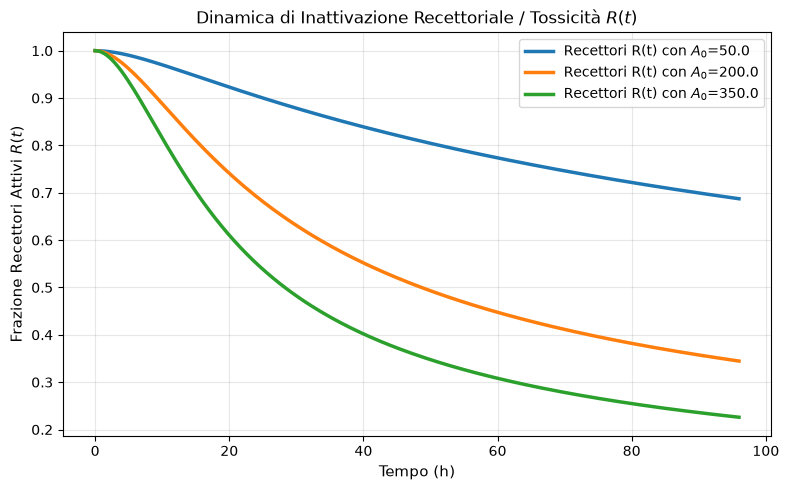

In [ ]:
# =============================================================================
# GRAFICO VISUALIZZAZIONE DELLA FRAZIONE DI RECETTORI ATTIVI R(t)
# =============================================================================
t_dense = np.linspace(0, 96, 200)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(8, 5))

for i, A0 in enumerate(A0_exp):
    sol = solve_ivp(
        ode_user3, (0, 96), [A0, 0.0, 1.0], 
        args=tuple(fit_user3.x), t_eval=t_dense, 
        method='RK45', rtol=1e-6, atol=1e-8
    )
    plt.plot(sol.t, sol.y[2], linewidth=2.5, color=colors[i], label=f'Recettori R(t) con $A_0$={A0}')

plt.title('Dinamica di Inattivazione Recettoriale $R(t)$', fontsize=12)
plt.xlabel('Tempo (h)', fontsize=11)
plt.ylabel('Frazione Recettori Attivi $R(t)$', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

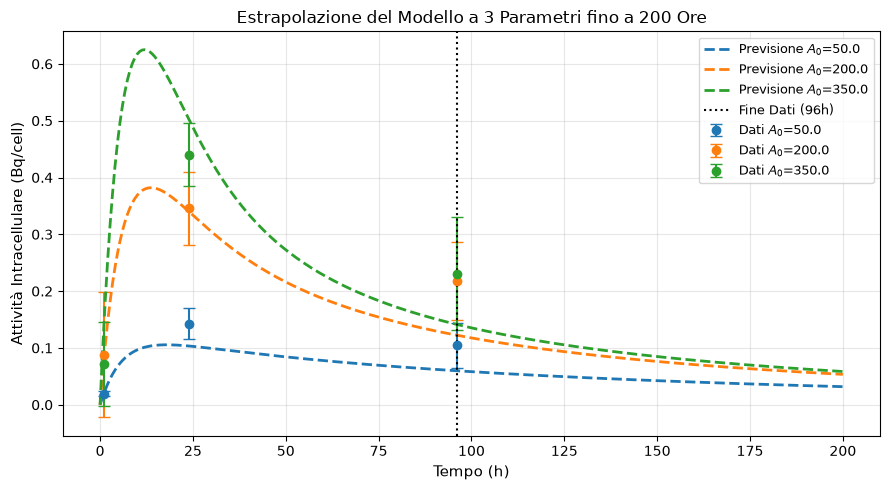

In [16]:
# =============================================================================
# ESTRAPOLAZIONE A LUNGO TERMINE (0 - 200 Ore)
# =============================================================================
t_future = np.linspace(0, 200, 300)

plt.figure(figsize=(9, 5))

for i, A0 in enumerate(A0_exp):
    sol_fut = solve_ivp(
        ode_user3, (0, 200), [A0, 0.0, 1.0], 
        args=tuple(fit_user3.x), t_eval=t_future, 
        method='RK45', rtol=1e-6, atol=1e-8
    )
    # Dati sperimentali (fino a 96h)
    plt.errorbar(t_exp, A_int_net[i, :], yerr=err_matrix[i, :], fmt='o', 
                 color=colors[i], capsize=4, label=f'Dati $A_0$={A0}')
    # Curva estrapolata (fino a 200h)
    plt.plot(sol_fut.t, sol_fut.y[1], '--', color=colors[i], 
             linewidth=2, label=f'Previsione $A_0$={A0}')

plt.axvline(96, color='black', linestyle=':', label='Fine Dati (96h)')
plt.title('Estrapolazione del Modello a 3 Parametri fino a 200 Ore', fontsize=12)
plt.xlabel('Tempo (h)', fontsize=11)
plt.ylabel('Attività Intracellulare (Bq/cell)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()